### SNOWPACK Test Case

Notebook contents 
* a place to document requirements for running SNOWPACK, looking at test case materials, etc. 
* also to take a look at the example SNOWPACK forcing files to double check precip and such

created by Cassie Lumbrazo\
last updated: Feb 2026\
run location: UAS linux\
python environment: **xarray**

In [4]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
# plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

In [28]:
# set some seaborn plotting constants so that all plots look the same
sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

In [5]:
pwd

'/home/cassie/python/repos/snow_model_forcing'

Location of SNOWPACK: `/home/cassie/programs/snowpack/`

# Run Test Case

Starting with a single station SNOWPACK run, 

so inside\
`/home/cassie/programs/snowpack/usr/share/doc/snowpack/examples`\
We have examples, such as `run_res1exp.sh` which is a simulation in research mode on the flat (from readme.txt)\
So I ran,\
> ./run_res1exp.sh

and it looks like everything ran well. Now, we can look inside the `\output` folder to see what's in there. 

--------------------

### `\input` and `\cfgfiles`
For the config files, there is the one,\
`io_res1exp.ini`

Could also go looking at the `\input` files for running the example to get an idea of structure.\
`MST96.smet`\
`MST96.sno`\

----------------------
from the `readme.text` within the SNOWPACK folder, 
### The necessary data set for these examples lies in "input" directory. 
* The files ".smet" or ".inp" contain meteorological time series.
* The files ".sno" contain the initial snow profiles in SMET format while the files ".snoold" contain these profiles in the legacy SNOWPACK format.
* The file ".meta" contains the metadata that can otherwise not be provided in the legacy "inp" meteo file format.
* See in the html documnetation of SNOWPACK and MeteoIO which files format are supported, how to specify which file format you want to use, which
options exist for each file format and how to easily add support for extra file formats.

### For running SNOWPACK,
* The simulations configurations files are contained in the "cfgfiles" directory. See in the html documentation how this configuration file is
structured.
* Very simple shell scripts call SNOWPACK with the necessary options. the last line of the script actually runs SNOWPACK and this last line
can be directly copied to the command line.
* Finally, the examples are written to the "output" directory.
--------------------

### `\output`
`MST96_res.ini` - ini file... a long list of variables and conditions\
`MST96_res.pro` - a *timeline* of simulated SNOWPACK profiles [PRO file]\
`MST96.smet` - a *timeseries* of meteorological forcing, fluxes, snow temperatures, etc. can be visualized [SMET file]\

Output visualiziation can be done with niViz, which is really made for these output files.\
* niViz for simulation output visualization (or go to https://niviz.org)

There are also single snow profile [CAAML file] files which were not in the output folder.

--------------------

# Read Example SMET Files
### Take a look at example forcing data to look at the structure, units, etc.

In [6]:
!pwd

/home/cassie/python/repos/snow_model_forcing


### Creating a function to read the smet files...
I know that this `snowpat` things exisits to do it, but I just prefer having my own scripts... lets see. 

In [7]:
def read_smet(filepath):
    header = {}
    fields = None
    data_start = None

    # Read file and parse header
    with open(filepath, "r") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        line = line.strip()

        # Detect fields line
        if line.startswith("fields"):
            fields = line.split("=")[1].strip().split()

        # Detect start of data
        if line == "[DATA]":
            data_start = i + 1
            break

        # Parse header key-value pairs
        if "=" in line and not line.startswith("["):
            key, value = line.split("=", 1)
            header[key.strip()] = value.strip()

    if fields is None:
        raise ValueError("No 'fields' line found in SMET header.")
    if data_start is None:
        raise ValueError("No [DATA] section found.")

    # Read data into DataFrame
    df = pd.read_csv(
        filepath,
        skiprows=data_start,
        delim_whitespace=True,
        names=fields,
        parse_dates=["timestamp"]
    )

    # Set timestamp as index
    df = df.set_index("timestamp")

    # Convert to xarray
    ds = xr.Dataset.from_dataframe(df)

    return ds, header

In [10]:
ds, header = read_smet("/home/cassie/python/models/run_snowpack/examples/MST96.smet")

print(ds)
print(header)

<xarray.Dataset> Size: 1MB
Dimensions:    (timestamp: 11088)
Coordinates:
  * timestamp  (timestamp) datetime64[ns] 89kB 1995-10-30T00:30:00 ... 1996-0...
Data variables: (12/14)
    TA         (timestamp) float64 89kB 273.1 273.1 273.1 ... 276.1 276.1 276.1
    RH         (timestamp) float64 89kB 0.958 0.958 0.958 ... 0.681 0.671 0.671
    TSG        (timestamp) float64 89kB 273.1 273.1 273.1 ... 273.1 273.1 273.1
    TSS        (timestamp) float64 89kB 273.4 273.4 273.4 ... 273.6 273.2 273.2
    HS         (timestamp) float64 89kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    VW         (timestamp) float64 89kB 0.8 0.8 0.8 0.8 0.8 ... 0.3 0.2 0.1 0.0
    ...         ...
    ISWR       (timestamp) int64 89kB 0 0 0 0 0 0 0 0 0 0 ... 31 5 0 0 0 0 0 0 0
    ILWR       (timestamp) int64 89kB 300 299 287 262 222 ... 226 225 225 225
    PSUM       (timestamp) float64 89kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    TS1        (timestamp) float64 89kB -999.0 -999.0 -999.0 ... -999.0 -999.0
   

/tmp/ipykernel_499614/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


In [11]:
ds

<xarray.Dataset> Size: 1MB
Dimensions:    (timestamp: 11088)
Coordinates:
  * timestamp  (timestamp) datetime64[ns] 89kB 1995-10-30T00:30:00 ... 1996-0...
Data variables: (12/14)
    TA         (timestamp) float64 89kB 273.1 273.1 273.1 ... 276.1 276.1 276.1
    RH         (timestamp) float64 89kB 0.958 0.958 0.958 ... 0.681 0.671 0.671
    TSG        (timestamp) float64 89kB 273.1 273.1 273.1 ... 273.1 273.1 273.1
    TSS        (timestamp) float64 89kB 273.4 273.4 273.4 ... 273.6 273.2 273.2
    HS         (timestamp) float64 89kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    VW         (timestamp) float64 89kB 0.8 0.8 0.8 0.8 0.8 ... 0.3 0.2 0.1 0.0
    ...         ...
    ISWR       (timestamp) int64 89kB 0 0 0 0 0 0 0 0 0 0 ... 31 5 0 0 0 0 0 0 0
    ILWR       (timestamp) int64 89kB 300 299 287 262 222 ... 226 225 225 225
    PSUM       (timestamp) float64 89kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    TS1        (timestamp) float64 89kB -999.0 -999.0 -999.0 ... -999.0 -999.0
    TS2        (timestamp) float64 89kB -999.0 -999.0 -999.0 ... -999.0 -999.0
    TS3        (timestamp) float64 89kB -999.0 -999.0 -999.0 ... -999.0 -999.0

In [15]:
# --- Unit expectations (SMET / MeteoIO) ---
# TA    : Kelvin
# RH    : fraction (0–1)
# VW    : m s-1
# DW    : degrees (meteorological)
# ISWR : W m-2
# ILWR : W m-2
# PSUM : mm per timestep
# P     : Pa

Text(0, 0.5, 'PSUM: precipitation (mm per timestep)')

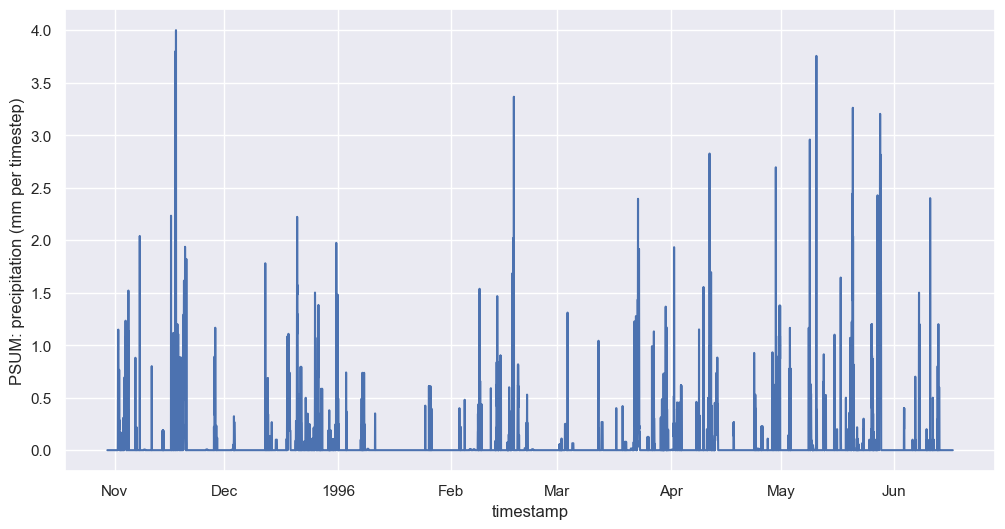

In [29]:
ds.PSUM.plot()
plt.ylabel("PSUM: precipitation (mm per timestep)")

### Important: precipitation units in SMET

In standard SNOWPACK SMET forcing:

> PSUM = precipitation rate

Units depend on configuration, but most common:

| Units   | Meaning              |
| ------- | -------------------- |
| mm/h    | millimeters per hour |
| kg/m²/h | equivalent to mm/h   |

So SNOWPACK expects **accumulated precipiation over the timestep** of the simulation


For Example,\
If the `timestep` = 1 hour, 
> PSUM = 1 mm/h 

If the `timestep` = 15 minutes, 
> PSUM = 0.25 mm per 15 min


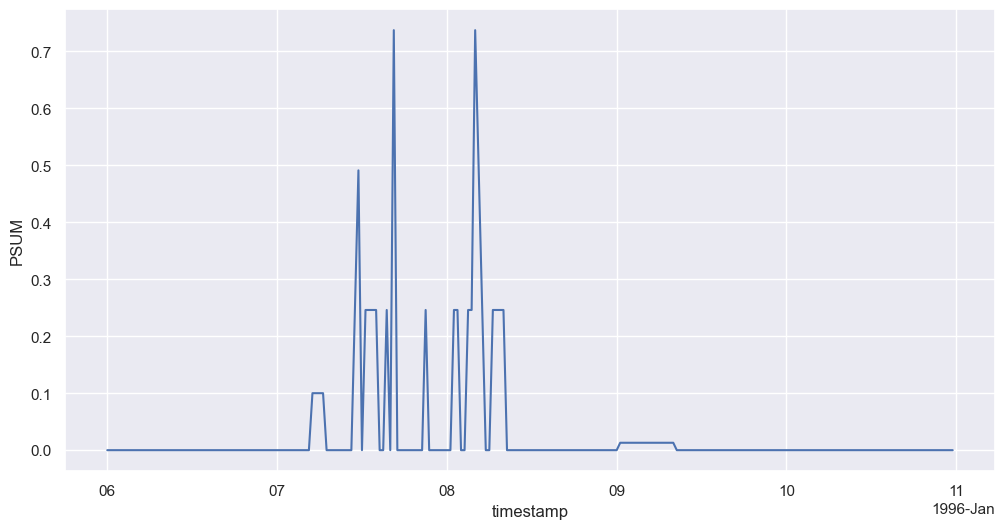

In [30]:
# zoom into a few days to see the timestepping
ds.PSUM.sel(timestamp=slice("1996-01-06", "1996-01-10")).plot()

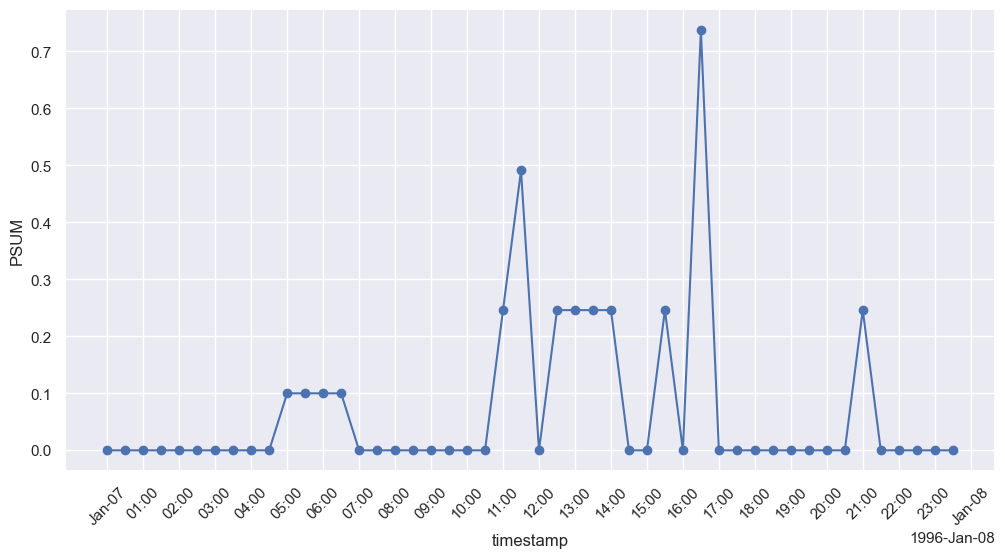

In [40]:
# zoom into a few days to see the timestepping
ds.PSUM.sel(timestamp=slice("1996-01-07", "1996-01-07")).plot(marker='o')
# add tick marks for every hour to see the timestepping more clearly
plt.xticks(pd.date_range("1996-01-07", "1996-01-08", freq="1h"), rotation=45)
plt.show()

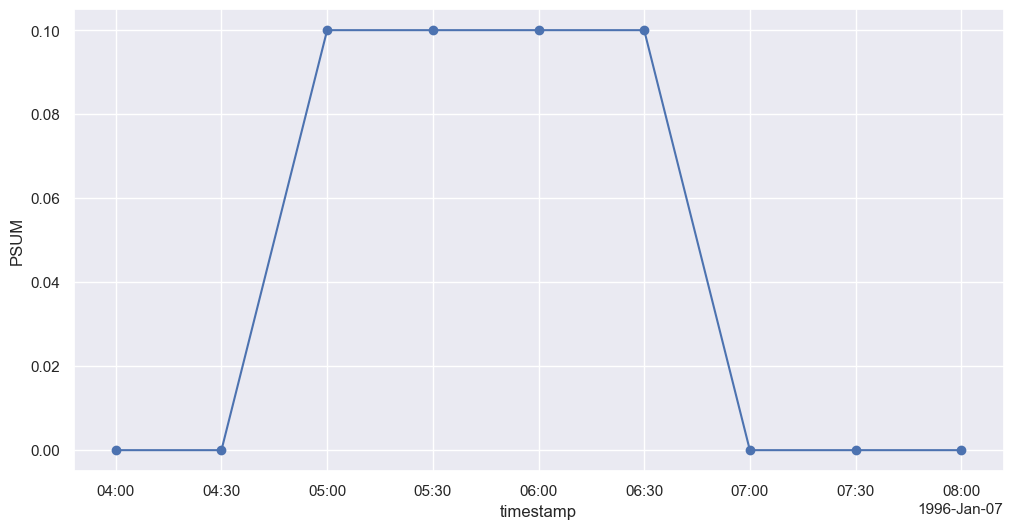

In [54]:
# zoom into a few days to see the timestepping
ds.PSUM.sel(timestamp=slice("1996-01-07 04:00", "1996-01-07 08:00")).plot(marker='o')
# add tick marks for every hour to see the timestepping more clearly
# plt.xticks(pd.date_range("1996-01-07", "1996-01-08", freq="1h"), rotation=45)
plt.show()

If values look like:

> 0–5 → likely mm/h\
> 0–0.005 → likely m/s or kg/m²/s

so this is certainly mm/h except, we are on 30 minutes simulation `timestamp`\
so I think it's mm/30 minutes

We can go back to our script `2_create_smet_forcing_files` to make sure the precipitation units are correct in mm/hr

we did that, now let's read it 

# Read Test SMET Files We Created, 

In [55]:
ds2, header2 = read_smet("/home/cassie/python/models/run_snowpack/test1/input/HRRR_POINT.smet")

ds2

/tmp/ipykernel_499614/1183788903.py:33: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


<xarray.Dataset> Size: 238kB
Dimensions:    (timestamp: 3312)
Coordinates:
  * timestamp  (timestamp) datetime64[ns] 26kB 2023-10-01T05:00:00 ... 2024-0...
Data variables:
    TA         (timestamp) float64 26kB 275.6 275.6 275.9 ... 274.6 273.7 273.2
    RH         (timestamp) float64 26kB 1.0 1.0 1.0 1.0 ... 0.276 0.256 0.244
    VW         (timestamp) float64 26kB 8.3 7.97 8.47 7.23 ... 2.84 2.56 2.54
    DW         (timestamp) float64 26kB 145.8 140.1 141.6 ... 80.0 87.8 87.2
    ISWR       (timestamp) float64 26kB 0.0 0.0 0.0 0.0 0.0 ... 70.0 0.0 0.0 0.0
    ILWR       (timestamp) float64 26kB 327.3 325.1 327.5 ... 218.2 218.1 219.2
    PSUM       (timestamp) float64 26kB 3.6 2.16 1.44 4.32 ... 0.0 0.0 0.0 0.0
    PS         (timestamp) float64 26kB 9.439e+04 9.43e+04 ... 9.521e+04

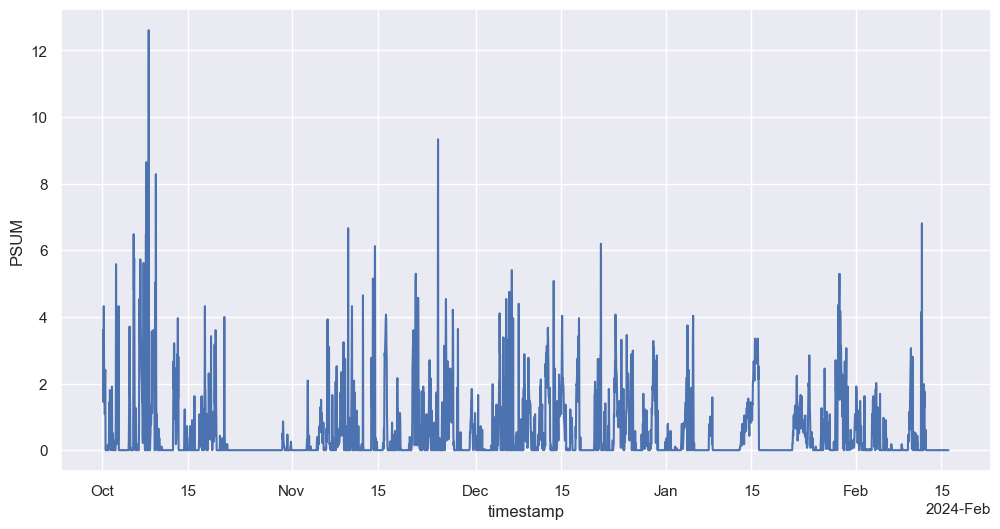

In [56]:
ds2.PSUM.plot()

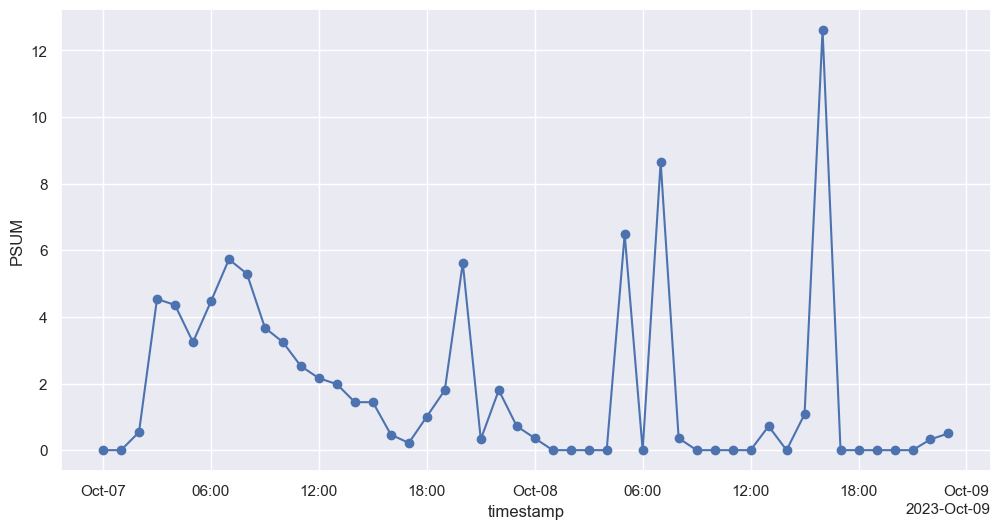

In [59]:
# zoom into a few days to see the timestepping
# ds2.PSUM.sel(timestamp=slice("2023-10-07 04:00", "2023-10-07 08:00")).plot(marker='o')
ds2.PSUM.sel(timestamp=slice("2023-10-07", "2023-10-08")).plot(marker='o')
# add tick marks for every hour to see the timestepping more clearly
plt.show()

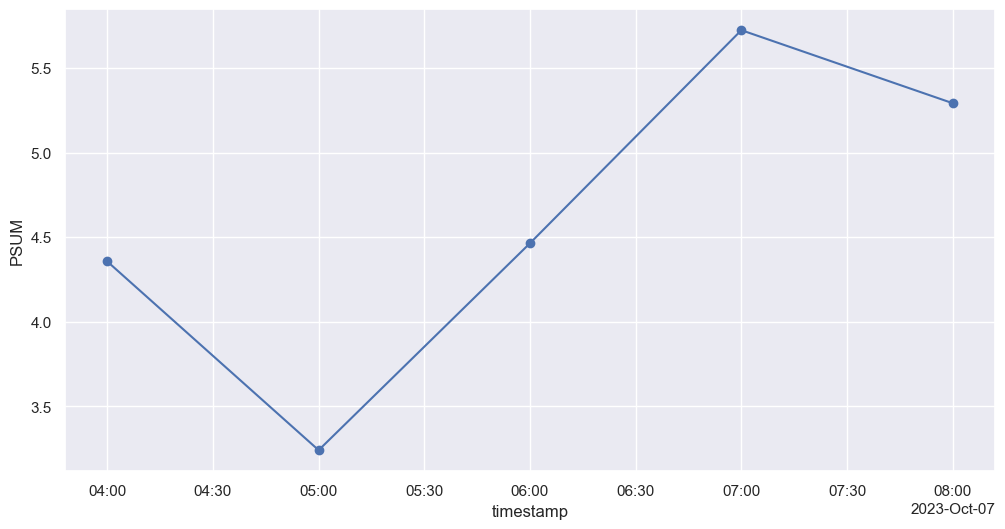

In [60]:
# zoom into a few days to see the timestepping
ds2.PSUM.sel(timestamp=slice("2023-10-07 04:00", "2023-10-07 08:00")).plot(marker='o')
# ds2.PSUM.sel(timestamp=slice("2023-10-07", "2023-10-08")).plot(marker='o')
# add tick marks for every hour to see the timestepping more clearly
plt.show()

Looks hourly, so it looks good. 